In [249]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATTERN = "hashjoin_*.csv"
RESULTS_CANDIDATES = [
    Path("results"),
    Path("src/results"),
    Path("../results"),
]

RESULTS_DIR = None
csv_files = []
for candidate_dir in RESULTS_CANDIDATES:
    candidate_files = sorted(candidate_dir.glob(CSV_PATTERN))
    if candidate_files:
        RESULTS_DIR = candidate_dir
        csv_files = candidate_files
        break

if not csv_files or RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No CSV files found with pattern {CSV_PATTERN} in: {searched}")

frames = []
for csv_path in csv_files:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    frames.append(current_df)

df = pd.concat(frames, ignore_index=True, sort=False)

numeric_columns = [
    "checksum1",
    "checksum2",
    "join_count",
    "join_threads",
    "join_throughput",
    "join_time",
    "max_key",
    "nr",
    "ns",
    "partition_threads",
    "partition_throughput",
    "partition_time",
    "time_sec",
    "total_throughput",
]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

fallback_total_throughput = (df["nr"] + df["ns"]) / df["time_sec"].where(df["time_sec"] > 0)
if "total_throughput" not in df.columns:
    df["total_throughput"] = fallback_total_throughput
else:
    df["total_throughput"] = df["total_throughput"].fillna(fallback_total_throughput)

exec_type_names = sorted(df["exec_type"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
exec_type_colors = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}


def resolve_img_dir():
    candidates = [
        Path("src/img"),
        Path("img"),
        Path("../src/img"),
        Path("../img"),
    ]
    for candidate in candidates:
        if candidate.parent.exists() or candidate.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = Path("img")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


IMG_DIR = resolve_img_dir()
PLOT_SAVE_COUNTER = 0


def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    if not cleaned:
        return "plot"
    return cleaned[:180]


def save_figure(fig, name_prefix):
    global PLOT_SAVE_COUNTER
    PLOT_SAVE_COUNTER += 1
    filename = f"{PLOT_SAVE_COUNTER:03d}_{slugify(name_prefix)}.png"
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")


def show_and_save(fig, name_prefix):
    save_figure(fig, name_prefix)
    plt.show()
    plt.close(fig)


print(f"[Loaded {df.shape[0]} runs from {RESULTS_DIR}]\n")
print("Files:")
for csv_path in csv_files:
    print(f"  - {csv_path.name}")

print("\nDistinct values:")
print(f"  exec_type: {exec_type_names}")
print(f"  max_key: {sorted(df['max_key'].dropna().unique())}")
print(f"  partition_threads: {sorted(df['partition_threads'].dropna().unique())}")
print(f"  join_threads: {sorted(df['join_threads'].dropna().unique())}")
print(f"  image_output_dir: {IMG_DIR}")


def _as_2d_axes(axes, nrows, ncols):
    if nrows == 1 and ncols == 1:
        return [[axes]]
    if nrows == 1:
        return [list(axes)]
    if ncols == 1:
        return [[ax] for ax in axes]
    return axes


def plot_thread_matrix(metric_df, metric_col, y_label, title_prefix, global_ymax=None, hline=None):
    required_cols = {
        "nr",
        "ns",
        "max_key",
        "partition_threads",
        "join_threads",
        "exec_type",
        metric_col,
    }
    missing_cols = sorted(required_cols - set(metric_df.columns))
    if missing_cols:
        print(f"Skipping {metric_col}: missing columns {missing_cols}")
        return

    for (fixed_nr, fixed_ns, fixed_max_key), subdf in metric_df.groupby(["nr", "ns", "max_key"]):
        part_values = sorted(subdf["partition_threads"].dropna().unique())
        join_values = sorted(subdf["join_threads"].dropna().unique())

        seq_ref = subdf[subdf["exec_type"] == "seq"]
        seq_value = (
            float(seq_ref[metric_col].mean())
            if not seq_ref.empty and pd.notna(seq_ref[metric_col].mean())
            else float("nan")
        )

        if pd.notna(seq_value):
            if 1 not in part_values:
                part_values = [1] + part_values
            if 1 not in join_values:
                join_values = [1] + join_values

        other_exec_types = sorted([e for e in subdf["exec_type"].dropna().unique() if e != "seq"])
        exec_types = (["seq"] if pd.notna(seq_value) else []) + other_exec_types

        if not exec_types or not part_values or not join_values:
            continue

        value_lookup = (
            subdf.dropna(subset=["partition_threads", "join_threads"])
            .set_index(["exec_type", "partition_threads", "join_threads"])[metric_col]
            .to_dict()
        )

        nrows = len(join_values)
        ncols = len(part_values)
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(max(3.2 * ncols, 8), max(2.6 * nrows, 6)),
            sharey=True,
        )
        axes_2d = _as_2d_axes(axes, nrows, ncols)

        for r, join_threads in enumerate(join_values):
            for c, part_threads in enumerate(part_values):
                ax = axes_2d[r][c]

                heights = []
                for exec_type in exec_types:
                    if exec_type == "seq":
                        value = seq_value if (part_threads == 1 and join_threads == 1) else float("nan")
                    else:
                        value = value_lookup.get((exec_type, part_threads, join_threads), float("nan"))
                    heights.append(value)

                x_positions = list(range(len(exec_types)))
                colors = [exec_type_colors.get(exec_type, "tab:gray") for exec_type in exec_types]
                ax.bar(x_positions, heights, color=colors)

                if pd.notna(global_ymax) and global_ymax > 0:
                    ax.set_ylim(0, global_ymax * 1.05)

                if hline is not None:
                    ax.axhline(float(hline), color="black", linestyle=":", linewidth=1.0, alpha=0.8)

                ax.set_xticks(x_positions)
                ax.set_xticklabels(exec_types, rotation=45, ha="right", fontsize=8)

                if r == 0:
                    ax.set_title(f"partition_threads={int(part_threads)}", fontsize=9)
                if c == 0:
                    ax.set_ylabel(f"join_threads={int(join_threads)}\n{y_label}", fontsize=8)

                ax.grid(axis="y", alpha=0.25)

        fig.suptitle(
            f"{title_prefix} matrix (nr={int(fixed_nr)}, ns={int(fixed_ns)}, max_key={int(fixed_max_key)})",
            y=1.02,
        )
        fig.tight_layout()
        show_and_save(
            fig,
            f"{title_prefix}_matrix_nr{int(fixed_nr)}_ns{int(fixed_ns)}_maxkey{int(fixed_max_key)}",
        )


[Loaded 505 runs from results]

Files:
  - hashjoin_par_p.csv
  - hashjoin_par_pj.csv
  - hashjoin_par_pj_wb.csv
  - hashjoin_par_pj_wb_map.csv
  - hashjoin_seq.csv

Distinct values:
  exec_type: ['par_p', 'par_pj', 'par_pj_wb', 'par_pj_wb_map', 'seq']
  max_key: [1000000]
  partition_threads: [1, 4, 8, 16, 32, 64]
  join_threads: [1, 4, 8, 16, 32, 64]
  image_output_dir: img


# Checksum validation

In [250]:
checksum_group_cols = ["nr", "ns", "max_key"]
summary_rows = []

for (nr, ns, max_key), subdf in df.groupby(checksum_group_cols):
    checksum_pairs = subdf[["checksum1", "checksum2"]].drop_duplicates()
    summary_rows.append({
        "nr": nr,
        "ns": ns,
        "max_key": max_key,
        "n_distinct_checksum_pairs": len(checksum_pairs),
        "is_valid": len(checksum_pairs) == 1,
        "exec_types": ", ".join(sorted(subdf["exec_type"].dropna().unique())),
    })

checksum_validation_df = (
    pd.DataFrame(summary_rows)
    .sort_values(checksum_group_cols)
    .reset_index(drop=True)
)

valid_groups = int(checksum_validation_df["is_valid"].sum()) if not checksum_validation_df.empty else 0
print(f"[OK groups: {valid_groups}/{len(checksum_validation_df)}]")
checksum_validation_df


[OK groups: 1/1]


,nr,ns,max_key,n_distinct_checksum_pairs,is_valid,exec_types
0,50000000,50000000,1000000,1,True,"par_p, par_pj, par_pj_wb, par_pj_wb_map, seq"


# Averaging

In [251]:
group_columns = [
    "checksum1",
    "checksum2",
    "nr",
    "ns",
    "max_key",
    "exec_type",
    "join_count",
    "join_threads",
    "partition_threads",
]

# Average every numeric field that is not part of the run-parameter key above.
avg_columns = [
    col for col in df.columns
    if col not in group_columns and pd.api.types.is_numeric_dtype(df[col])
]

stable_avg_df = (
    df.groupby(group_columns, as_index=False)
    .agg({col: "mean" for col in avg_columns})
    .sort_values(group_columns)
    .reset_index(drop=True)
)

print(f"non_averaged={df.shape}\n\t{df.columns}")
display(df.head(5))
print(f"averaged={stable_avg_df.shape}\n\t{stable_avg_df.columns}")
display(stable_avg_df.head(5))

non_averaged=(505, 15)
	Index(['checksum1', 'checksum2', 'join_count', 'join_threads',
       'join_throughput', 'join_time', 'max_key', 'nr', 'ns',
       'partition_threads', 'partition_throughput', 'partition_time',
       'time_sec', 'total_throughput', 'exec_type'],
      dtype='object')


,checksum1,checksum2,join_count,join_threads,join_throughput,join_time,max_key,nr,ns,partition_threads,partition_throughput,partition_time,time_sec,total_throughput,exec_type
0,6185417096973469475,16931092769743058723,2499986166,4,4.040445e+07,2.474975,1000000,50000000,50000000,4,1.092147e+08,0.915628,3.392912,2.947321e+07,par_p
1,6185417096973469475,16931092769743058723,2499986166,8,4.011965e+07,2.492544,1000000,50000000,50000000,4,1.084575e+08,0.922020,3.416821,2.926697e+07,par_p
2,6185417096973469475,16931092769743058723,2499986166,16,4.887495e+07,2.046038,1000000,50000000,50000000,4,1.090449e+08,0.917054,2.965345,3.372288e+07,par_p
3,6185417096973469475,16931092769743058723,2499986166,32,4.881763e+07,2.048440,1000000,50000000,50000000,4,1.088010e+08,0.919109,2.969865,3.367157e+07,par_p
4,6185417096973469475,16931092769743058723,2499986166,64,4.079358e+07,2.451366,1000000,50000000,50000000,4,1.083901e+08,0.922593,3.376197,2.961912e+07,par_p


averaged=(101, 15)
	Index(['checksum1', 'checksum2', 'nr', 'ns', 'max_key', 'exec_type',
       'join_count', 'join_threads', 'partition_threads', 'join_throughput',
       'join_time', 'partition_throughput', 'partition_time', 'time_sec',
       'total_throughput'],
      dtype='object')


,checksum1,checksum2,nr,ns,max_key,exec_type,join_count,join_threads,partition_threads,join_throughput,join_time,partition_throughput,partition_time,time_sec,total_throughput
0,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,4,4.391655e+07,2.296605,1.088893e+08,0.918371,3.217214,3.121363e+07
1,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,8,4.520071e+07,2.226311,1.664839e+08,0.600664,2.829213,3.548525e+07
2,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,16,4.384876e+07,2.299376,2.323468e+08,0.430407,2.732077,3.681502e+07
3,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,32,4.687109e+07,2.143384,2.737656e+08,0.365287,2.511127,3.995832e+07
4,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,64,4.707142e+07,2.133691,2.725036e+08,0.367025,2.503308,4.007098e+07


# Partition time

[saved] img/001_partition_time_matrix_nr50000000_ns50000000_maxkey1000000.png


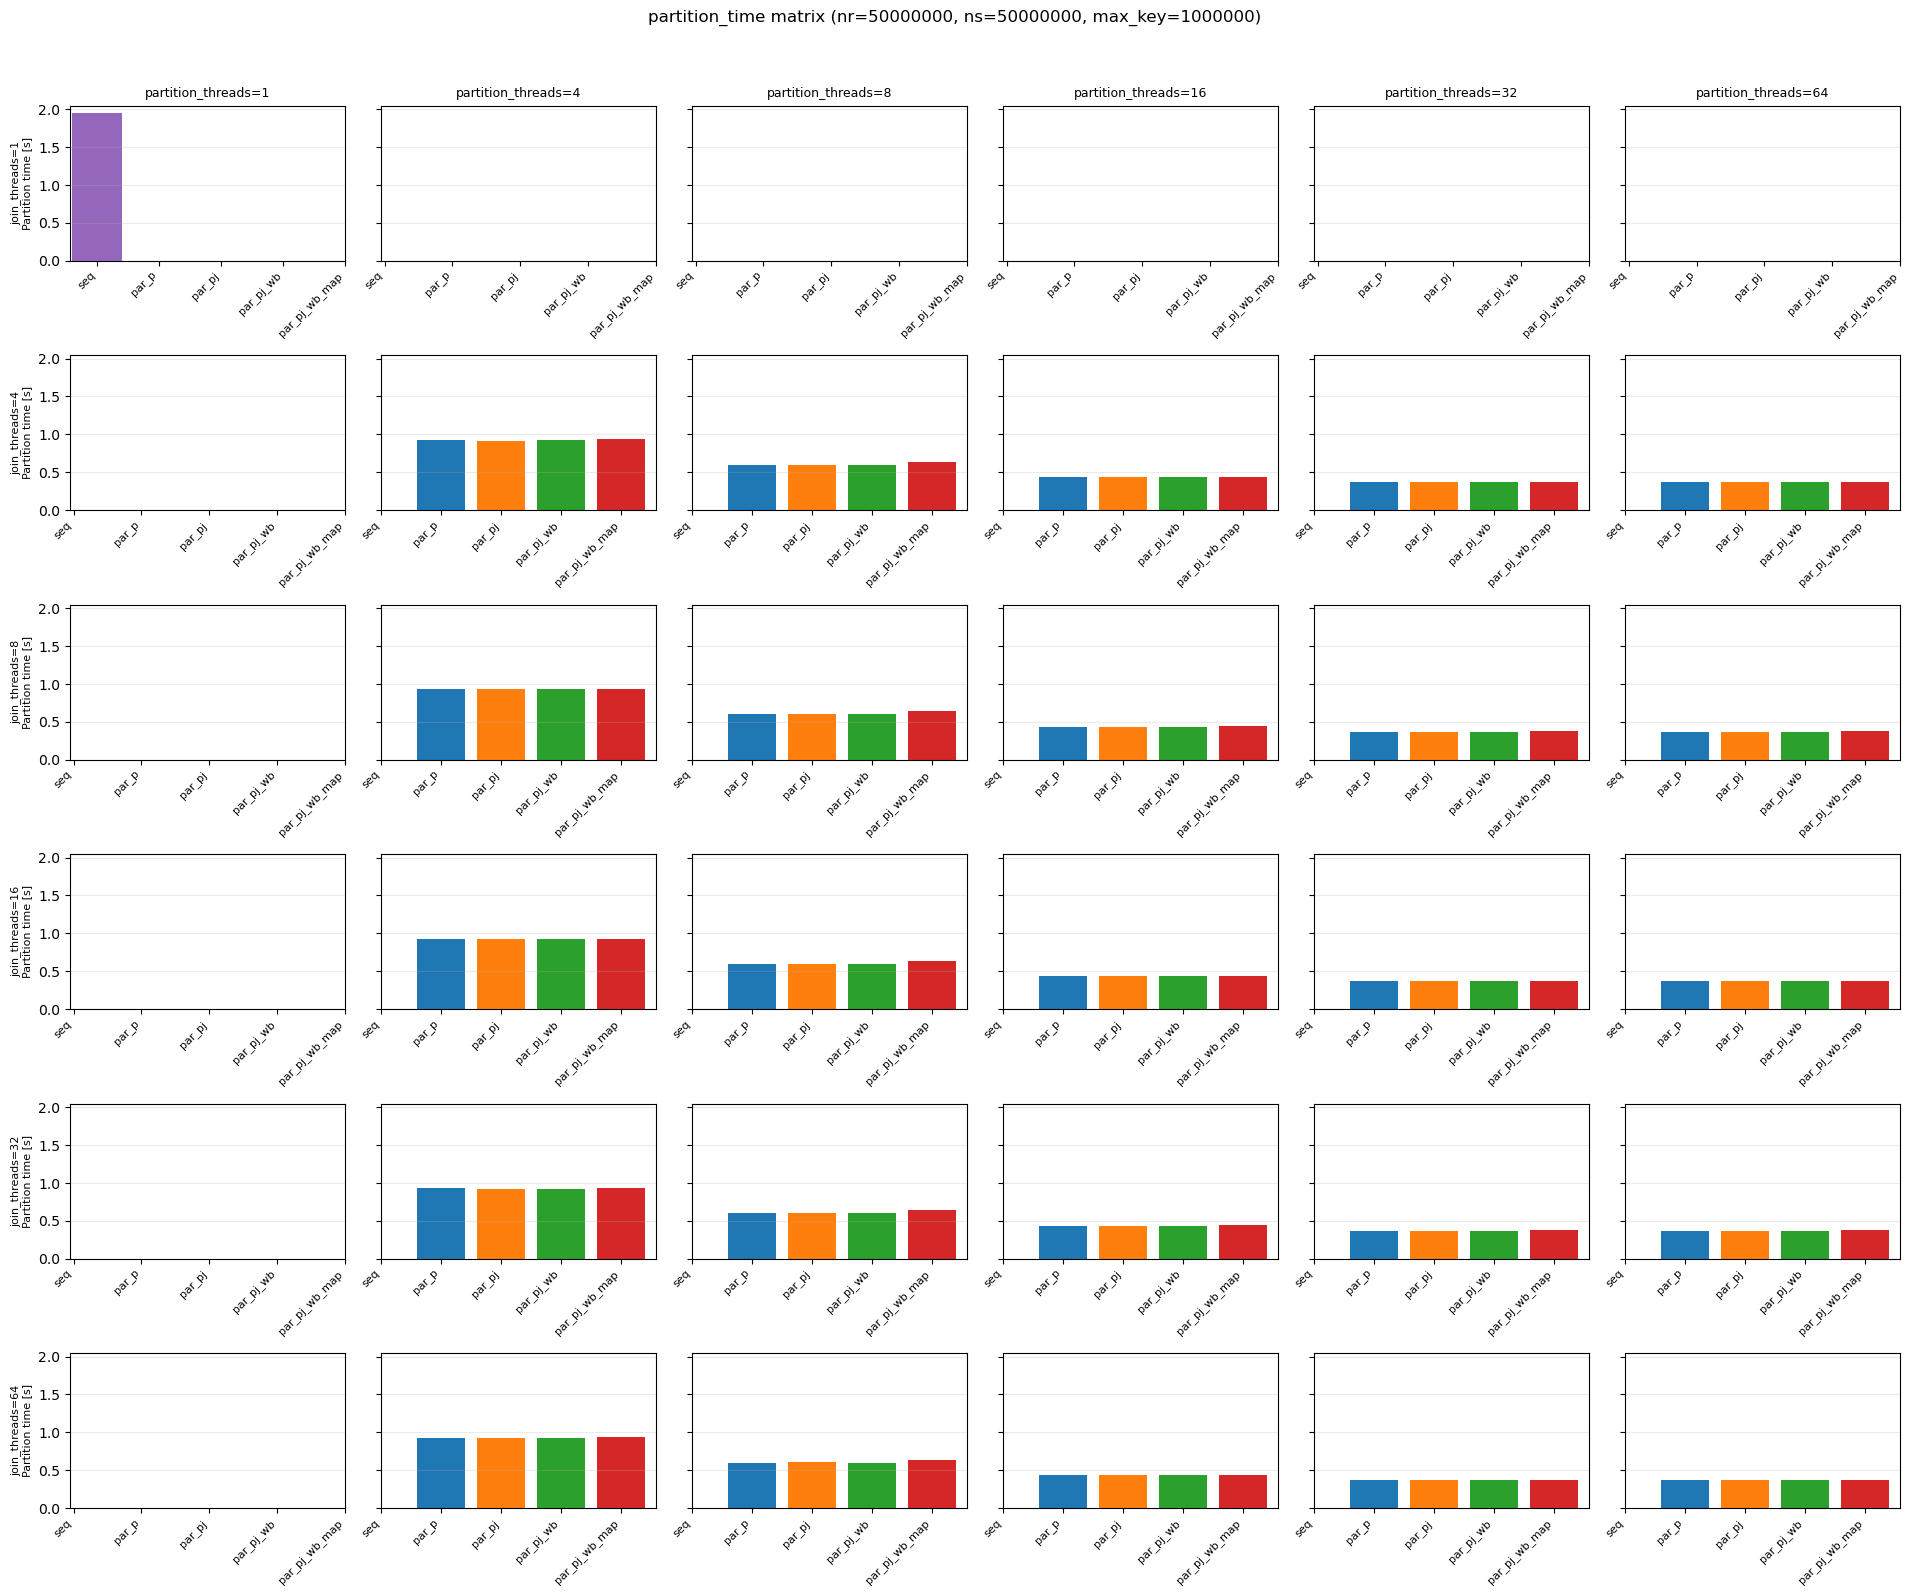

In [252]:
global_partition_time_ymax = stable_avg_df["partition_time"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="partition_time",
    y_label="Partition time [s]",
    title_prefix="partition_time",
    global_ymax=global_partition_time_ymax,
)


# Partition time standard deviation

[saved] img/002_std_partition_time_by_max_key.png


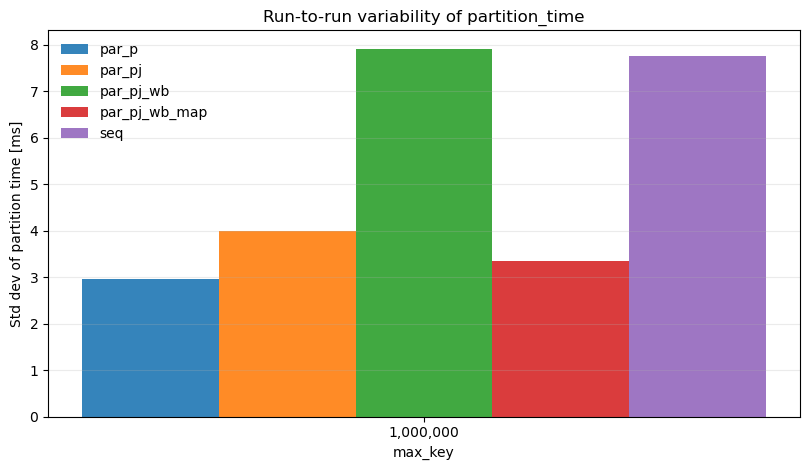

,checksum1,checksum2,join_count,join_threads,max_key,nr,ns,partition_threads,exec_type,std_partition_time,std_ms
0,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,4,par_p,0.002952,2.952419
1,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,8,par_p,0.001963,1.963002
2,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,16,par_p,0.002978,2.977703
3,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,32,par_p,0.002310,2.310268
4,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,64,par_p,0.005123,5.123388
...,...,...,...,...,...,...,...,...,...,...,...
96,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,8,par_pj_wb_map,0.000772,0.772313
97,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,16,par_pj_wb_map,0.003342,3.341998
98,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,32,par_pj_wb_map,0.001054,1.053924
99,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,64,par_pj_wb_map,0.004847,4.847241


In [253]:
std_df = (
    df.groupby([col for col in df.columns if col in group_columns], as_index=False)
    .agg(std_partition_time=("partition_time", "std"))
)
std_df["std_ms"] = std_df["std_partition_time"] * 1e3

max_key_values = sorted(std_df["max_key"].dropna().unique())
exec_types = sorted(std_df["exec_type"].dropna().unique())

x_positions = list(range(len(max_key_values)))
bar_width = 0.8 / len(exec_types) if exec_types else 0.8

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for idx, exec_type in enumerate(exec_types):
    heights = []
    for max_key in max_key_values:
        sub = std_df[(std_df["max_key"] == max_key) & (std_df["exec_type"] == exec_type)]
        heights.append(float(sub["std_ms"].iloc[0]) if not sub.empty else float("nan"))

    offsets = [
        x + (idx - (len(exec_types) - 1) / 2) * bar_width
        for x in x_positions
    ]
    ax.bar(
        offsets,
        heights,
        width=bar_width,
        label=exec_type,
        color=exec_type_colors.get(exec_type, "tab:gray"),
        alpha=0.9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"{int(v):,}" for v in max_key_values])
ax.set_xlabel("max_key")
ax.set_ylabel("Std dev of partition time [ms]")
ax.set_title("Run-to-run variability of partition_time")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
show_and_save(fig, "std_partition_time_by_max_key")

std_df.sort_values(["max_key", "exec_type"]).reset_index(drop=True)


# Join time

[saved] img/003_join_time_matrix_nr50000000_ns50000000_maxkey1000000.png


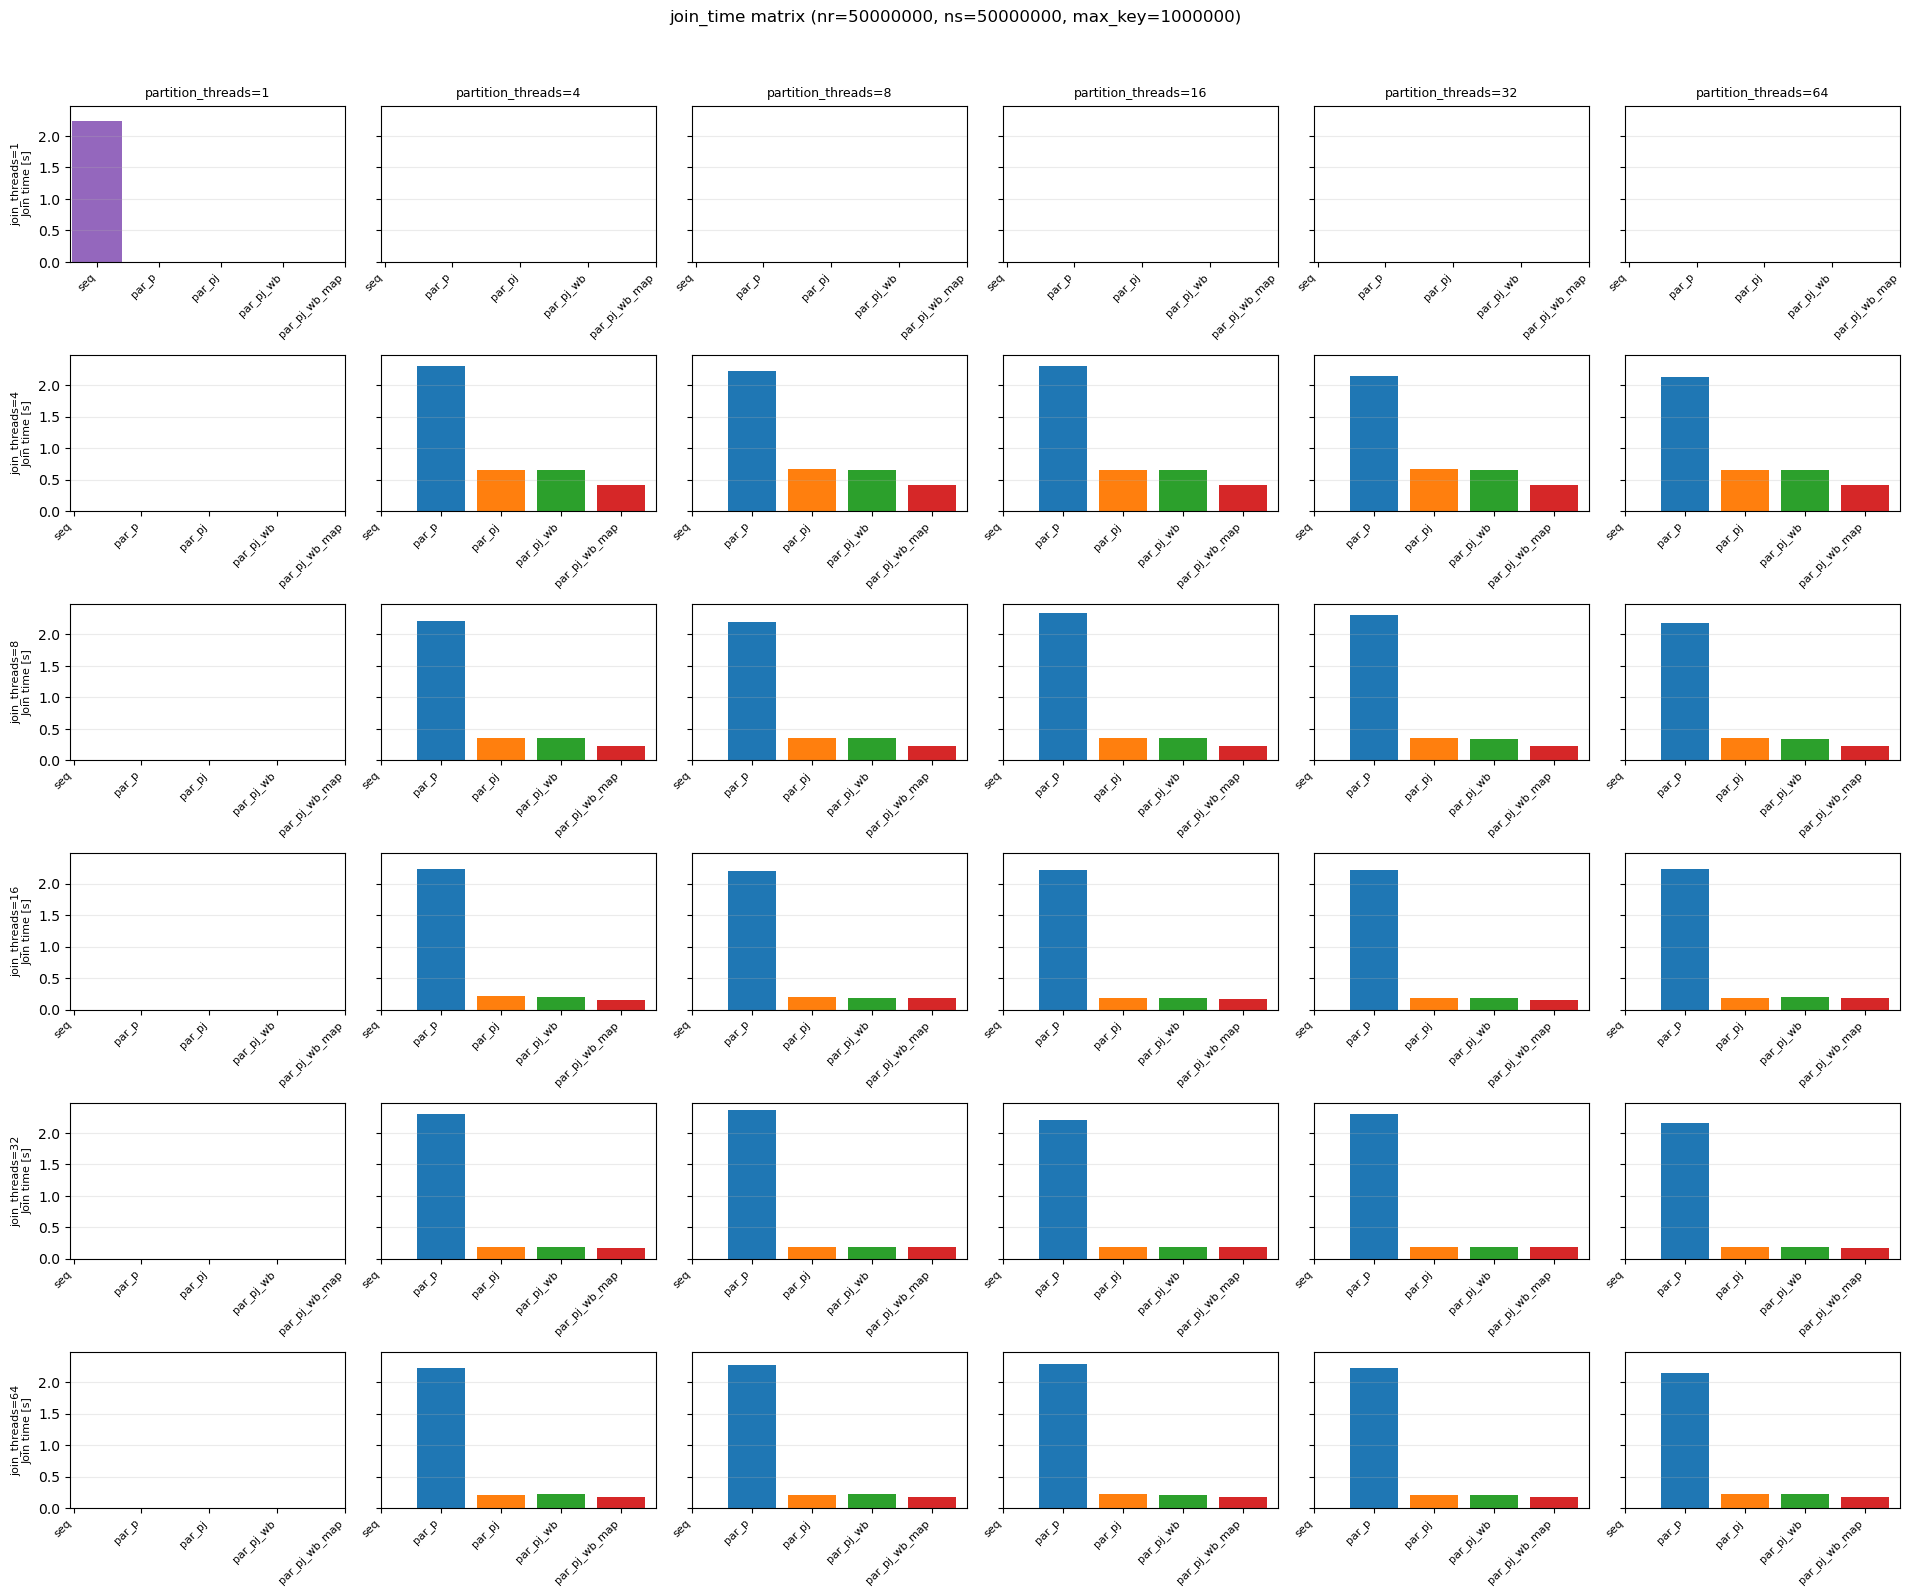

In [254]:
global_join_time_ymax = stable_avg_df["join_time"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="join_time",
    y_label="Join time [s]",
    title_prefix="join_time",
    global_ymax=global_join_time_ymax,
)


# Join time standard deviation

[saved] img/004_std_join_time_by_max_key.png


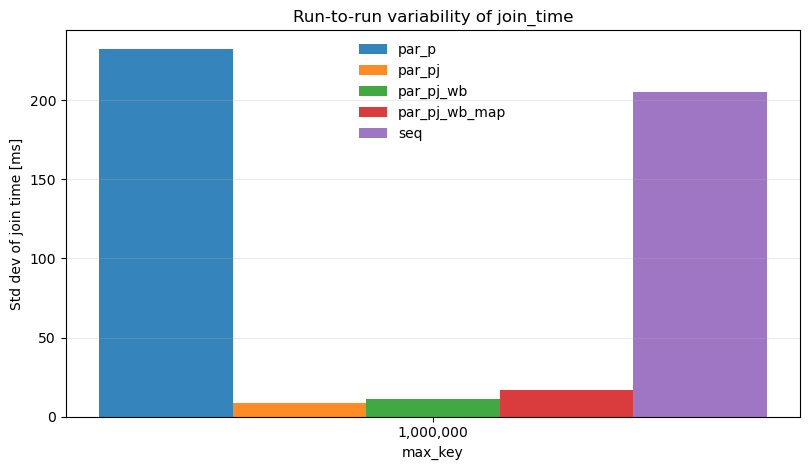

,checksum1,checksum2,join_count,join_threads,max_key,nr,ns,partition_threads,exec_type,std_join_time,std_ms
0,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,4,par_p,0.232601,232.601458
1,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,8,par_p,0.199954,199.953883
2,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,16,par_p,0.228358,228.357591
3,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,32,par_p,0.170849,170.848753
4,6185417096973469475,16931092769743058723,2499986166,4,1000000,50000000,50000000,64,par_p,0.165005,165.005486
...,...,...,...,...,...,...,...,...,...,...,...
96,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,8,par_pj_wb_map,0.004216,4.215586
97,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,16,par_pj_wb_map,0.008506,8.506053
98,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,32,par_pj_wb_map,0.010496,10.496046
99,6185417096973469475,16931092769743058723,2499986166,64,1000000,50000000,50000000,64,par_pj_wb_map,0.004920,4.920337


In [255]:
std_df = (
    df.groupby([col for col in df.columns if col in group_columns], as_index=False)
    .agg(std_join_time=("join_time", "std"))
)
std_df["std_ms"] = std_df["std_join_time"] * 1e3

max_key_values = sorted(std_df["max_key"].dropna().unique())
exec_types = sorted(std_df["exec_type"].dropna().unique())

x_positions = list(range(len(max_key_values)))
bar_width = 0.8 / len(exec_types) if exec_types else 0.8

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for idx, exec_type in enumerate(exec_types):
    heights = []
    for max_key in max_key_values:
        sub = std_df[(std_df["max_key"] == max_key) & (std_df["exec_type"] == exec_type)]
        heights.append(float(sub["std_ms"].iloc[0]) if not sub.empty else float("nan"))

    offsets = [
        x + (idx - (len(exec_types) - 1) / 2) * bar_width
        for x in x_positions
    ]
    ax.bar(
        offsets,
        heights,
        width=bar_width,
        label=exec_type,
        color=exec_type_colors.get(exec_type, "tab:gray"),
        alpha=0.9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"{int(v):,}" for v in max_key_values])
ax.set_xlabel("max_key")
ax.set_ylabel("Std dev of join time [ms]")
ax.set_title("Run-to-run variability of join_time")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
show_and_save(fig, "std_join_time_by_max_key")

std_df.sort_values(["max_key", "exec_type"]).reset_index(drop=True)


# Total time

[saved] img/005_time_sec_matrix_nr50000000_ns50000000_maxkey1000000.png


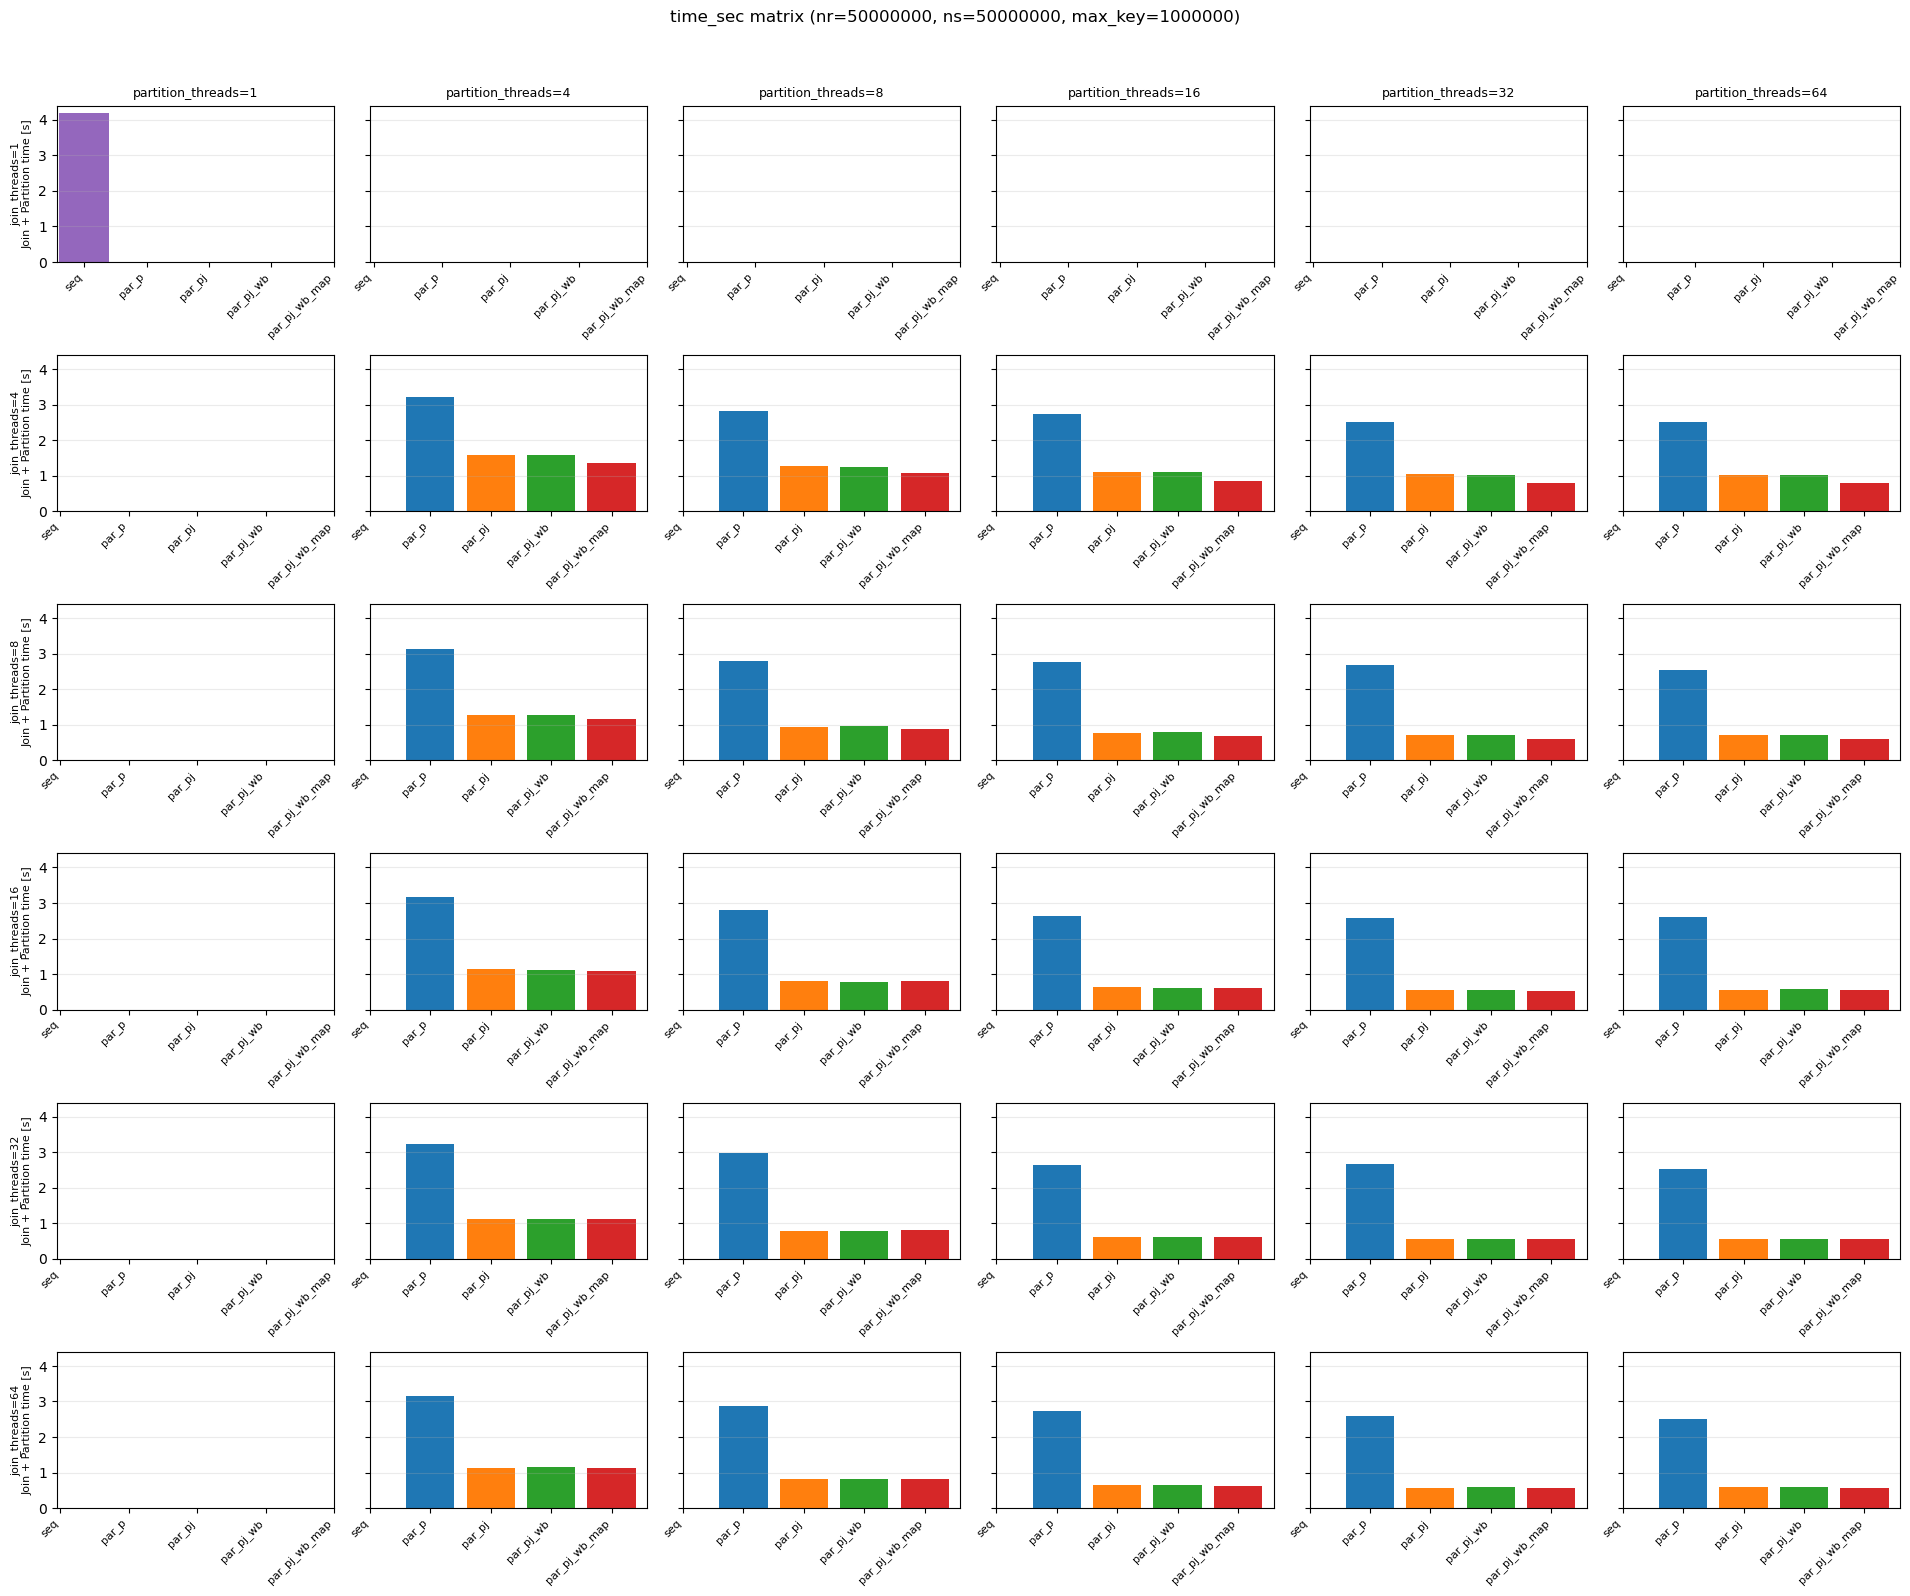

In [256]:
global_tot_time_ymax = stable_avg_df["time_sec"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="time_sec",
    y_label="Join + Partition time [s]",
    title_prefix="time_sec",
    global_ymax=global_tot_time_ymax,
)

# Speedup

In [257]:
baseline_exec_type = "seq"

baseline_df = (
    stable_avg_df[stable_avg_df["exec_type"] == baseline_exec_type][
        ["nr", "ns", "max_key", "total_throughput"]
    ]
    .groupby(["nr", "ns", "max_key"], as_index=False)
    .agg(baseline_total_throughput=("total_throughput", "mean"))
)

if baseline_df.empty:
    raise ValueError("No seq baseline available for speedup computation")

speedup_avg_df = stable_avg_df.merge(
    baseline_df,
    on=["nr", "ns", "max_key"],
    how="left",
)

speedup_avg_df["speedup_total_throughput"] = (
    speedup_avg_df["total_throughput"] / speedup_avg_df["baseline_total_throughput"]
)
speedup_avg_df.loc[speedup_avg_df["baseline_total_throughput"] <= 0, "speedup_total_throughput"] = float("nan")

speedup_avg_df.head(10)


,checksum1,checksum2,nr,ns,max_key,exec_type,join_count,join_threads,partition_threads,join_throughput,join_time,partition_throughput,partition_time,time_sec,total_throughput,baseline_total_throughput,speedup_total_throughput
0,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,4,4.391655e+07,2.296605,1.088893e+08,0.918371,3.217214,3.121363e+07,2.390911e+07,1.305512
1,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,8,4.520071e+07,2.226311,1.664839e+08,0.600664,2.829213,3.548525e+07,2.390911e+07,1.484173
2,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,16,4.384876e+07,2.299376,2.323468e+08,0.430407,2.732077,3.681502e+07,2.390911e+07,1.539790
3,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,32,4.687109e+07,2.143384,2.737656e+08,0.365287,2.511127,3.995832e+07,2.390911e+07,1.671259
4,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,4,64,4.707142e+07,2.133691,2.725036e+08,0.367025,2.503308,4.007098e+07,2.390911e+07,1.675971
5,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,8,4,4.550518e+07,2.215488,1.077168e+08,0.928452,3.146184,3.191238e+07,2.390911e+07,1.334737
6,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,8,8,4.580279e+07,2.199622,1.666785e+08,0.599982,2.802032,3.585358e+07,2.390911e+07,1.499578
7,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,8,16,4.297036e+07,2.340336,2.323345e+08,0.430418,2.773037,3.620386e+07,2.390911e+07,1.514229
8,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,8,32,4.373892e+07,2.304291,2.731606e+08,0.366090,2.672748,3.763397e+07,2.390911e+07,1.574043
9,6185417096973469475,16931092769743058723,50000000,50000000,1000000,par_p,2499986166,8,64,4.611253e+07,2.180593,2.747944e+08,0.363932,2.547193,3.942406e+07,2.390911e+07,1.648914


[saved] img/006_speedup_total_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


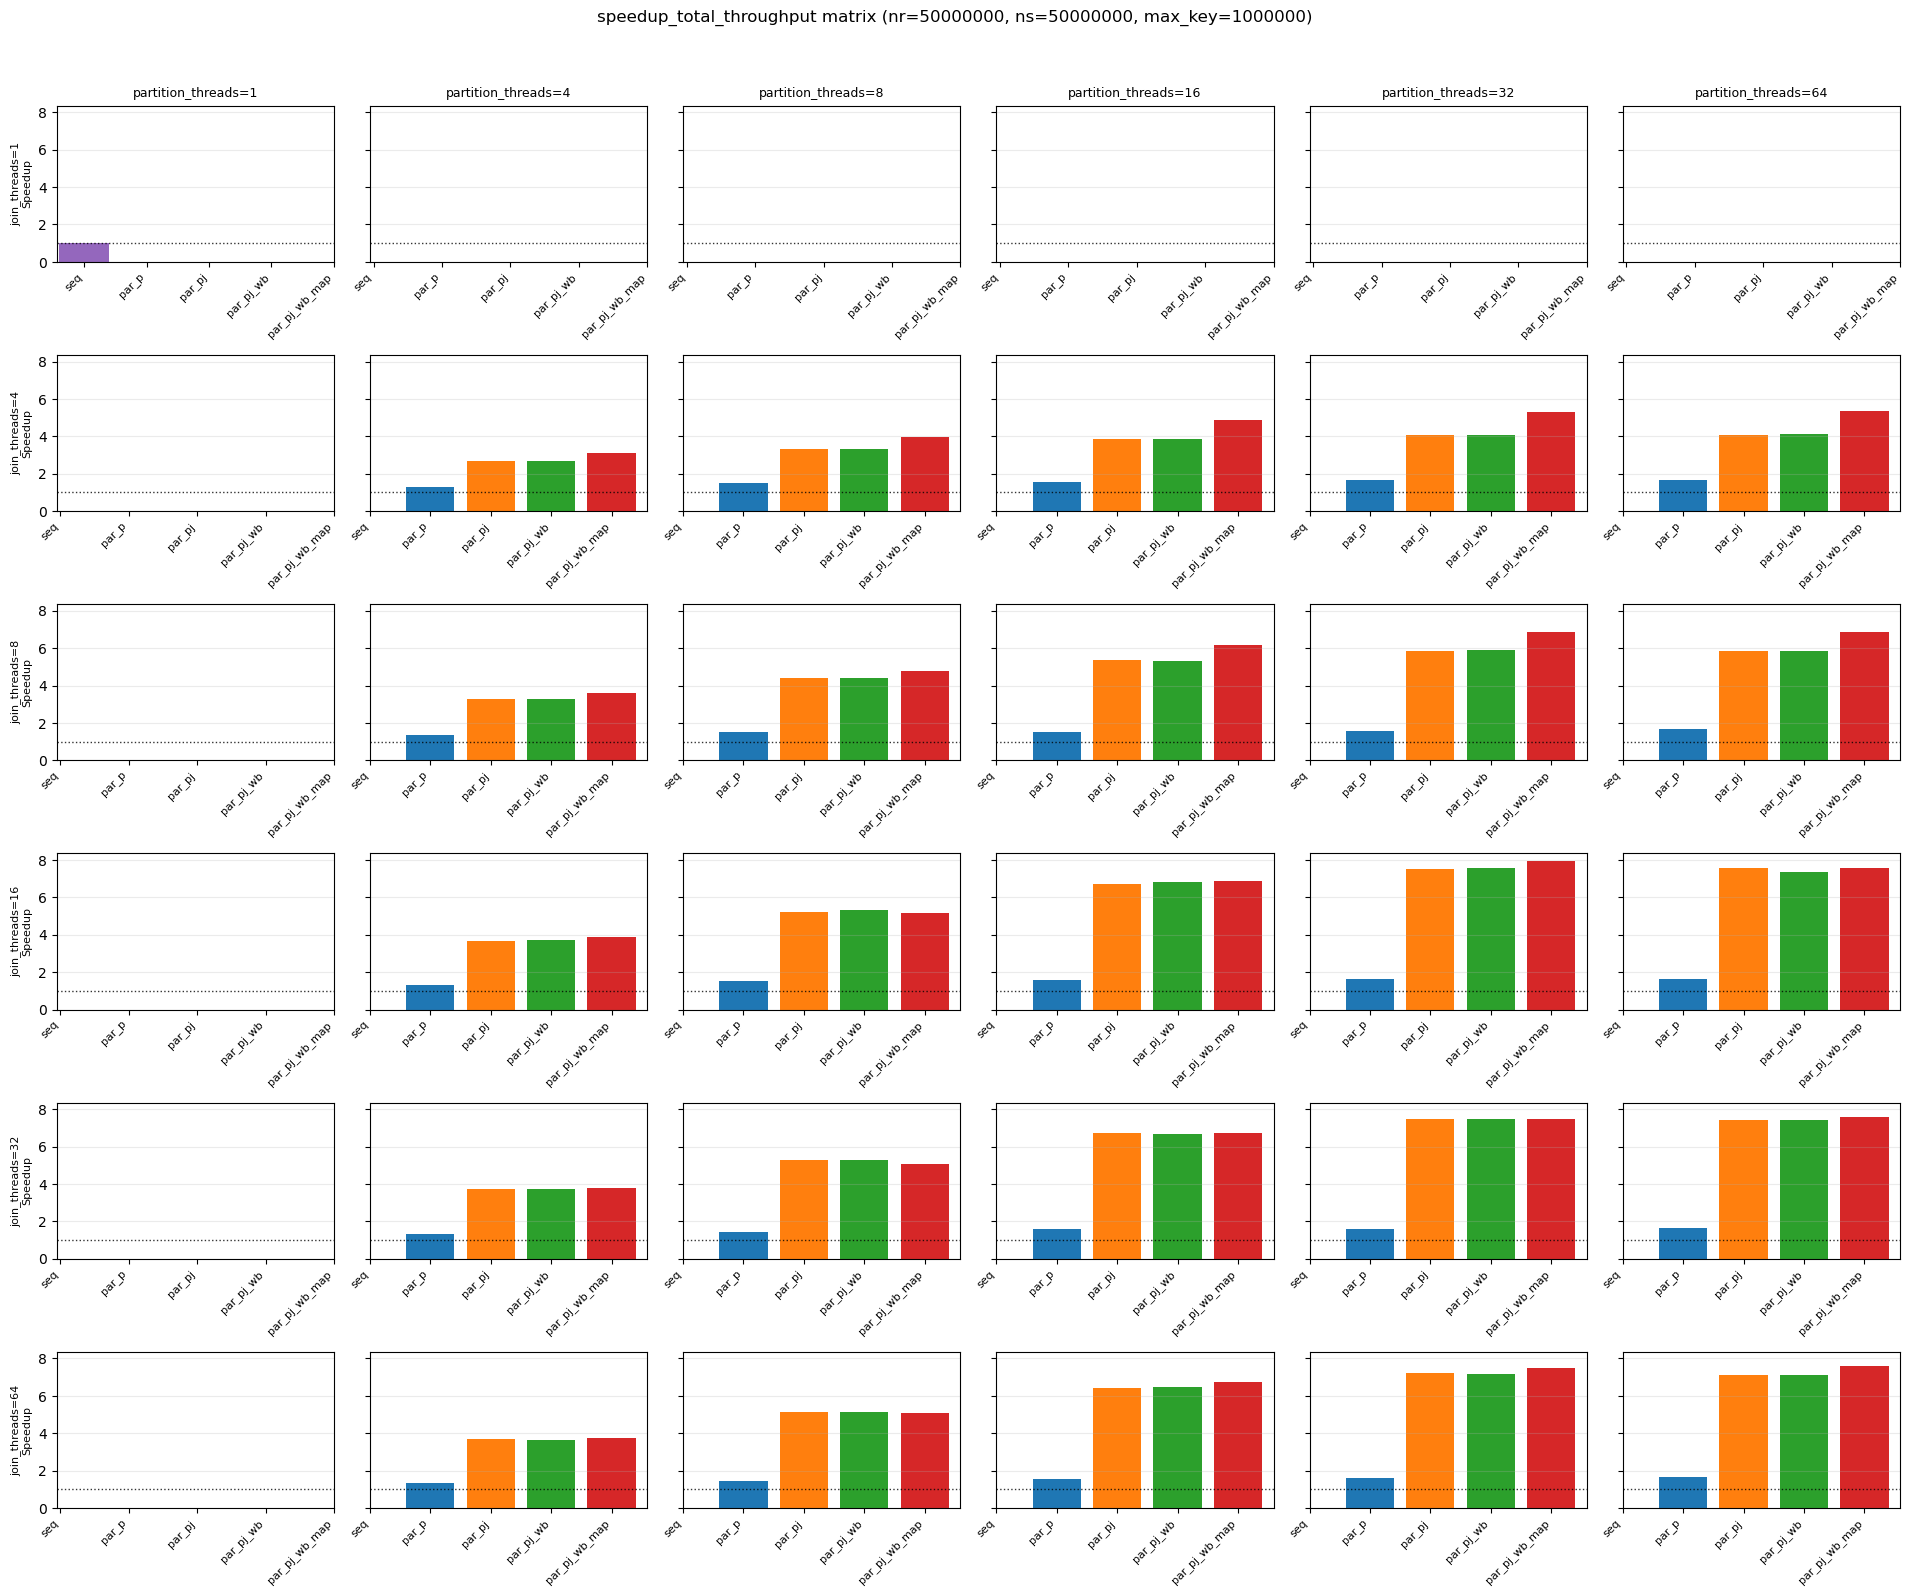

In [258]:
global_speedup_ymax = speedup_avg_df["speedup_total_throughput"].max()
plot_thread_matrix(
    speedup_avg_df,
    metric_col="speedup_total_throughput",
    y_label="Speedup",
    title_prefix="speedup_total_throughput",
    global_ymax=global_speedup_ymax,
    hline=1.0,
)


# Throughput

[saved] img/007_partition_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


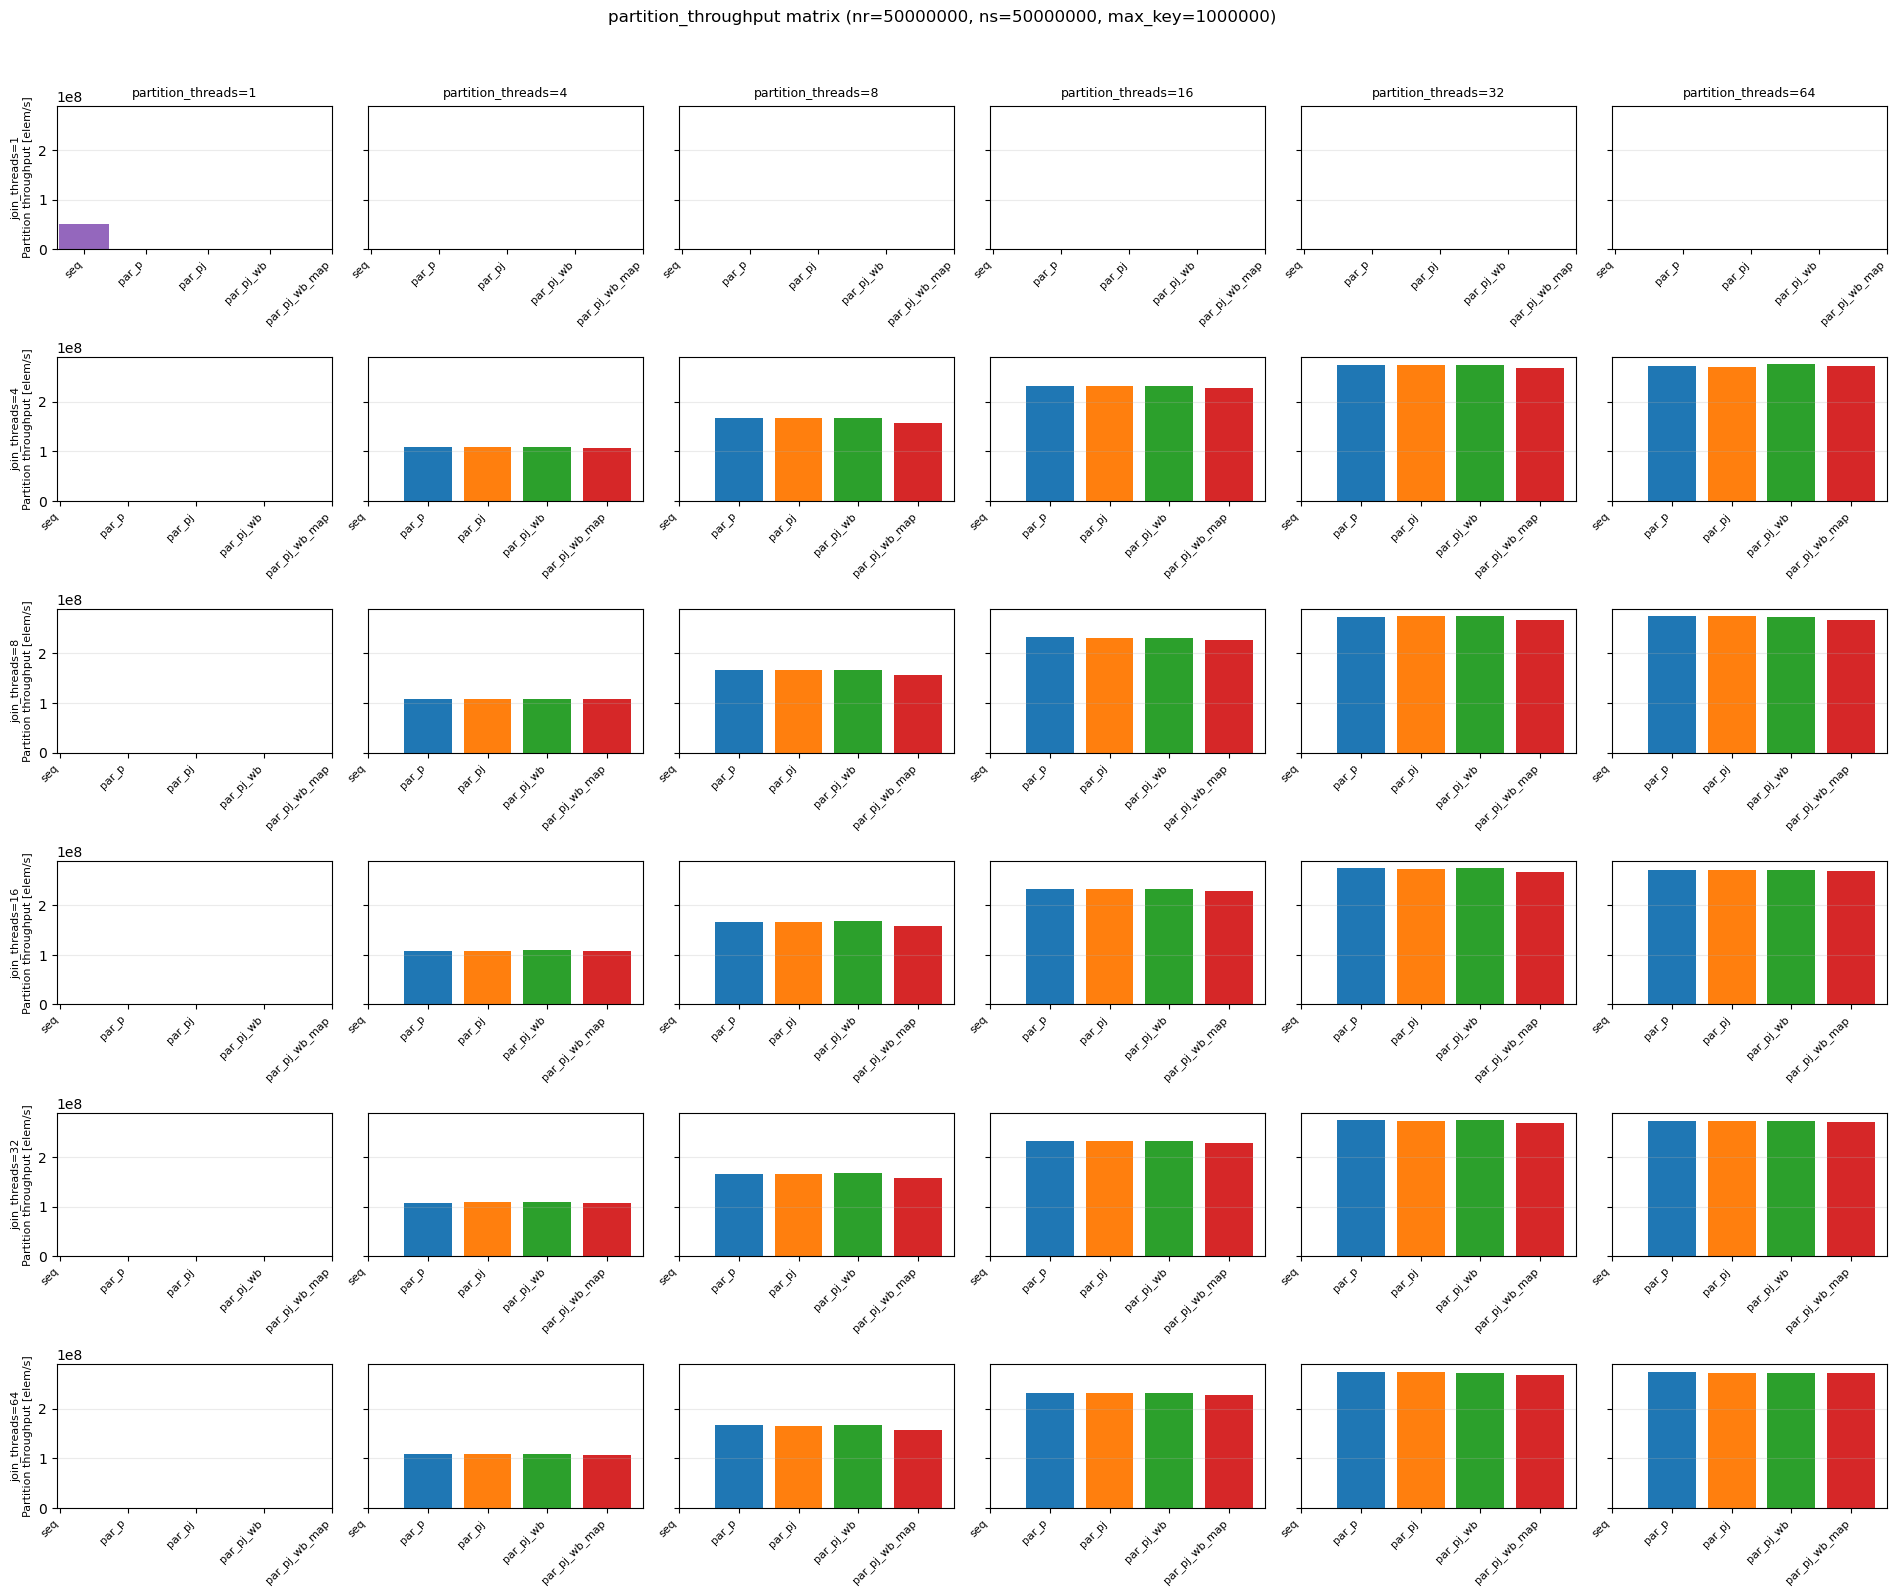

[saved] img/008_join_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


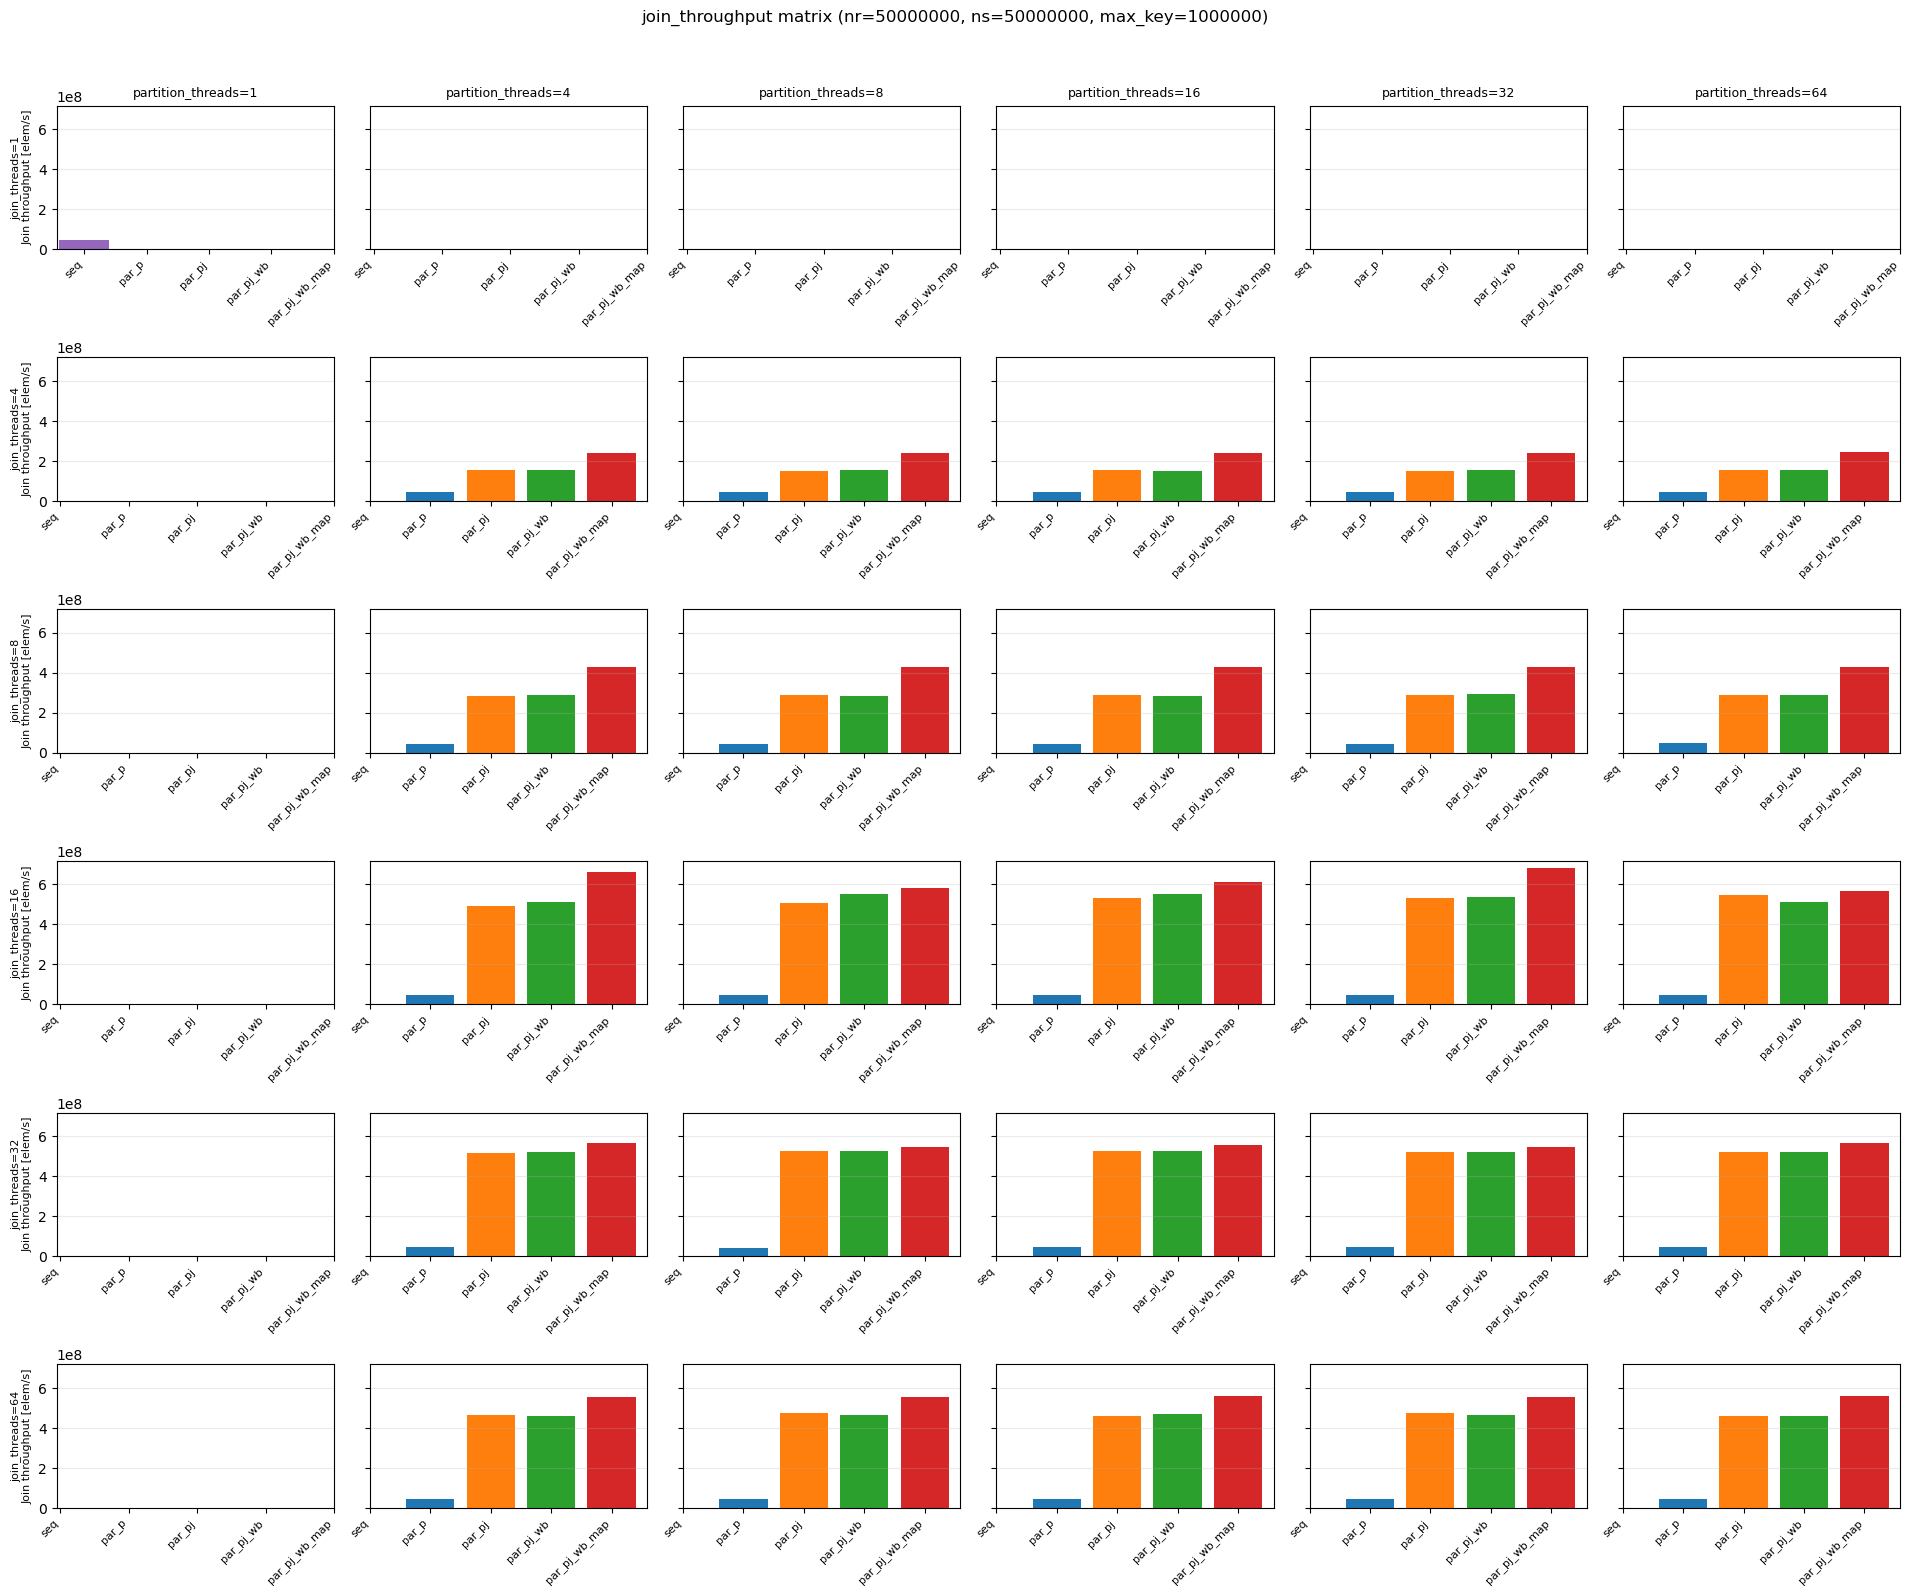

[saved] img/009_total_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


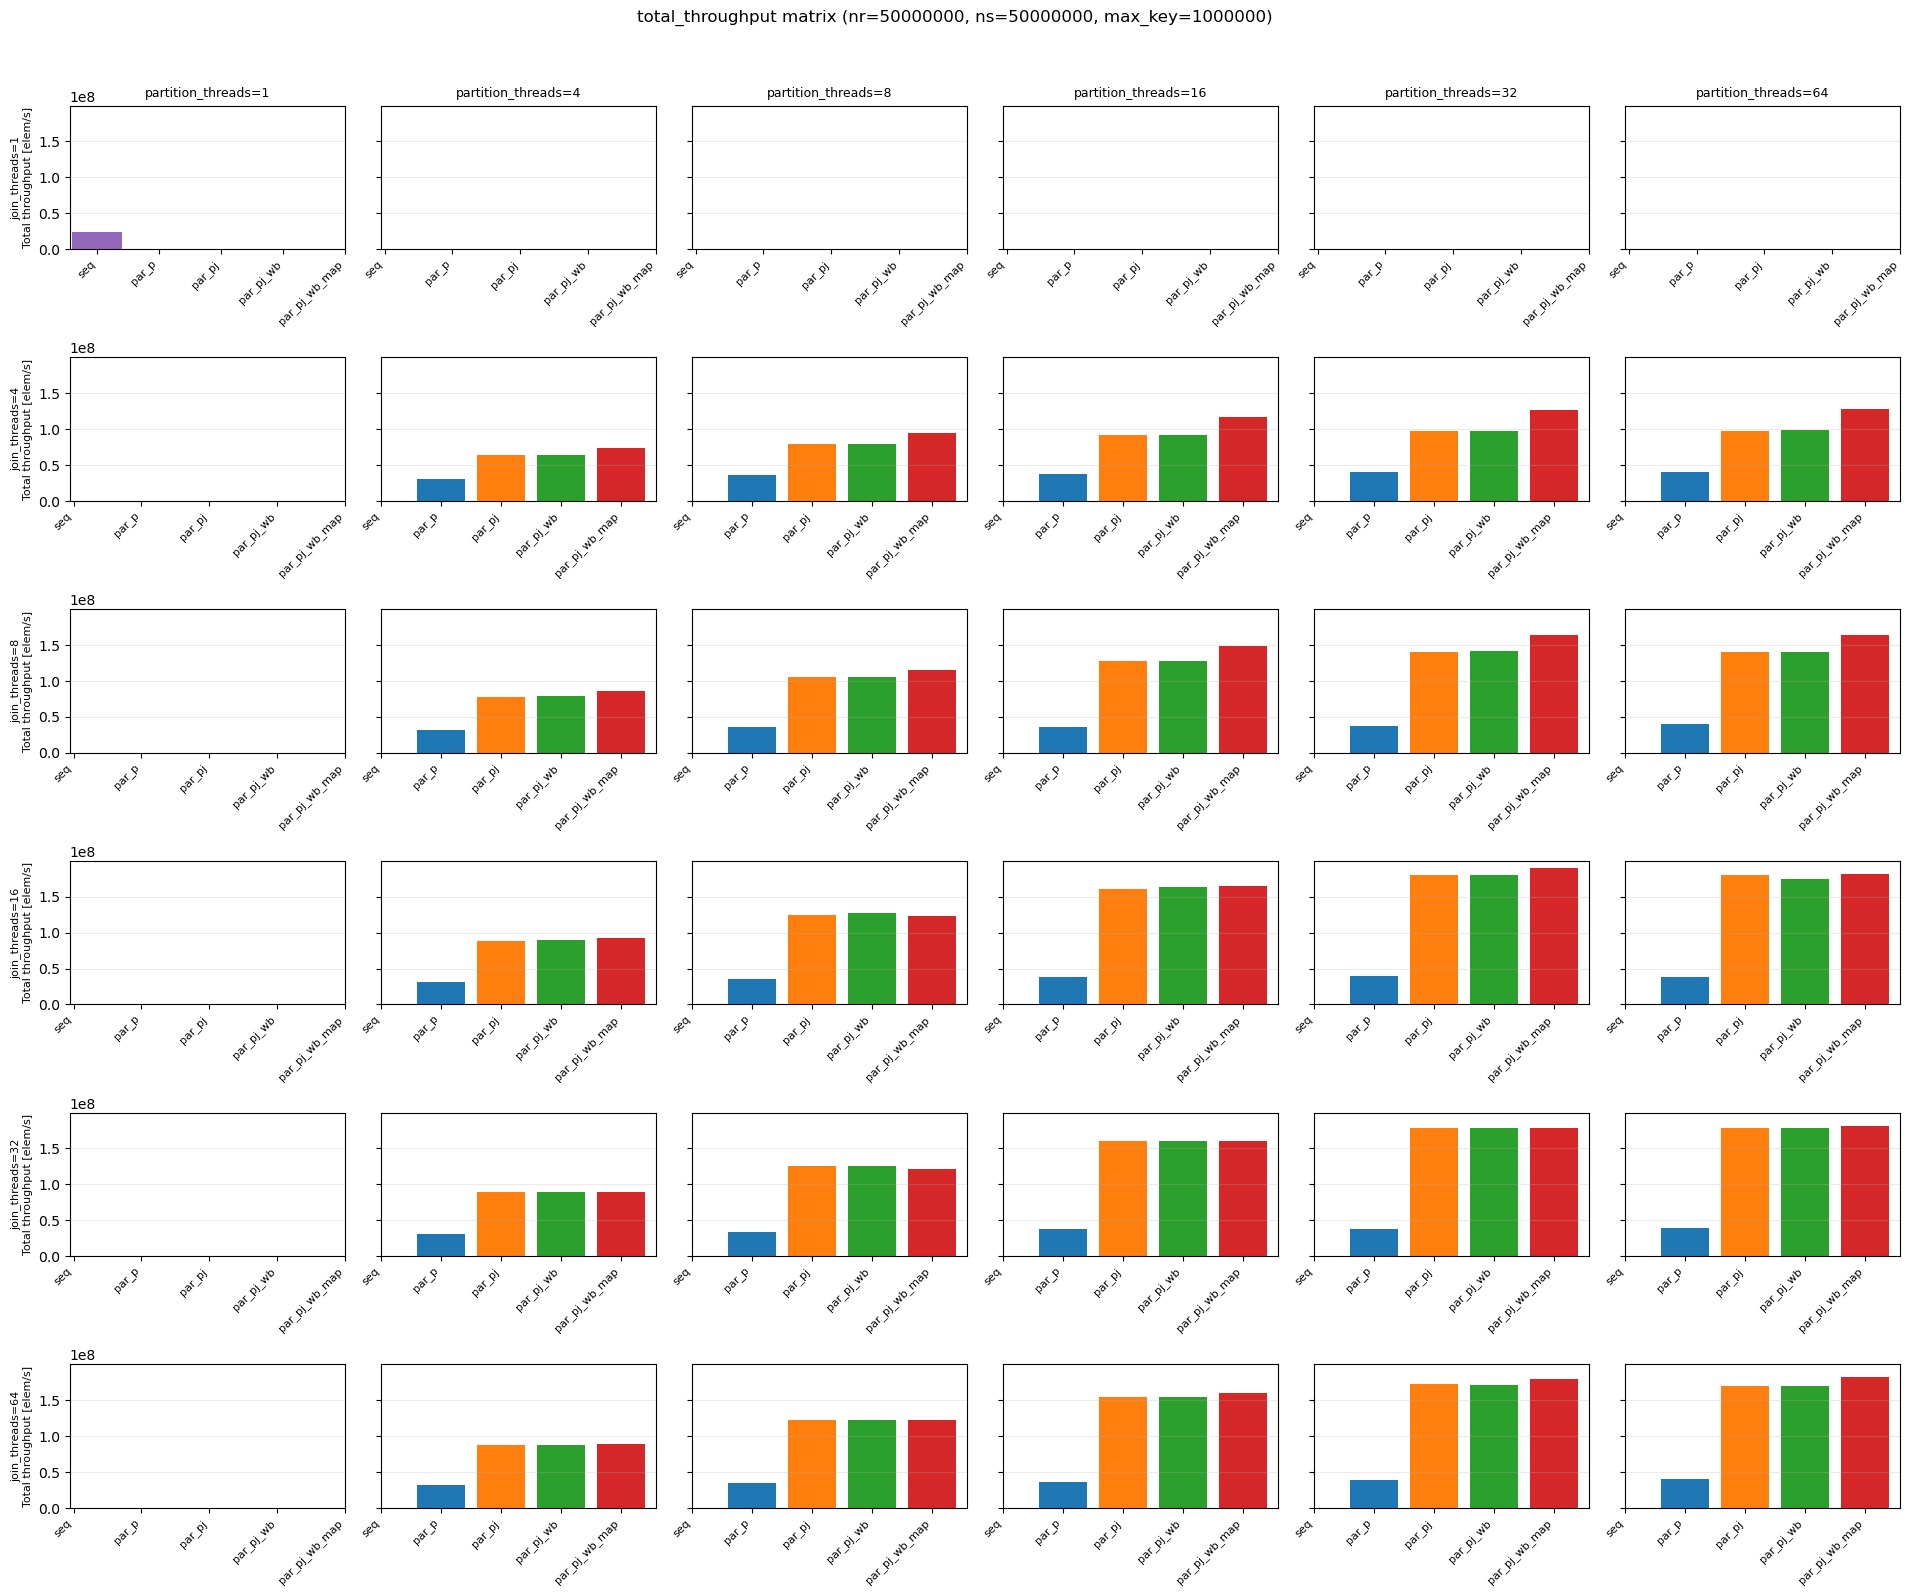

In [259]:
throughput_metrics = [
    ("partition_throughput", "Partition throughput [elem/s]"),
    ("join_throughput", "Join throughput [elem/s]"),
    ("total_throughput", "Total throughput [elem/s]"),
]

for metric_col, ylabel in throughput_metrics:
    if metric_col not in stable_avg_df.columns:
        continue

    global_metric_ymax = stable_avg_df[metric_col].max()
    plot_thread_matrix(
        stable_avg_df,
        metric_col=metric_col,
        y_label=ylabel,
        title_prefix=metric_col,
        global_ymax=global_metric_ymax,
    )


# Weak scaling

[weak-scaling csv] results/weak_scaling.csv
[N values] [10000000, 20000000, 40000000, 80000000]
[baseline speedup] 1.0
[rows plotted] 16
[saved] img/010_weak_scaling_speedup_vs_threads_by_N_weak_scaling.png


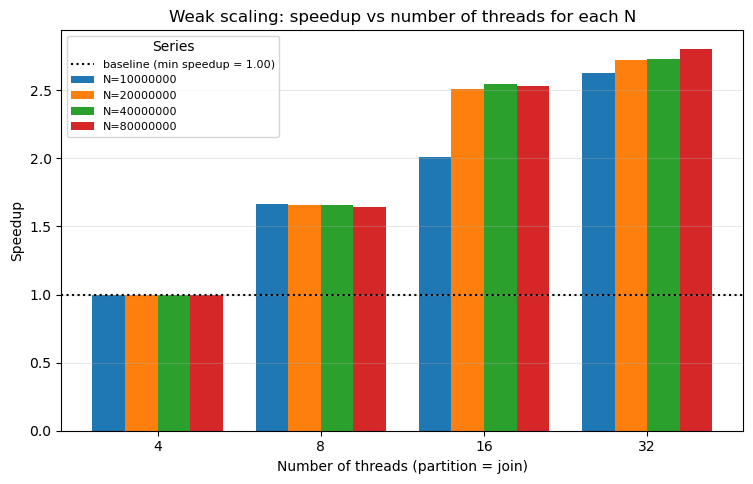

In [260]:
weak_scaling_candidates = []
for candidate_dir in RESULTS_CANDIDATES:
    weak_scaling_candidates.extend(sorted(candidate_dir.glob("*weak*scaling*.csv")))

# Keep insertion order while removing duplicates.
weak_scaling_candidates = list(dict.fromkeys(weak_scaling_candidates))
if not weak_scaling_candidates:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No weak-scaling CSV found in: {searched}")

weak_scaling_path = weak_scaling_candidates[0]
weak_df = pd.read_csv(weak_scaling_path)

for col in ["nr", "ns", "partition_threads", "join_threads", "total_throughput", "time_sec"]:
    if col in weak_df.columns:
        weak_df[col] = pd.to_numeric(weak_df[col], errors="coerce")

if "nr" not in weak_df.columns:
    raise KeyError("Weak-scaling CSV must contain column 'nr'")

if "partition_threads" in weak_df.columns and "join_threads" in weak_df.columns:
    weak_df = weak_df[weak_df["partition_threads"] == weak_df["join_threads"]].copy()
    threads_col = "partition_threads"
elif "partition_threads" in weak_df.columns:
    threads_col = "partition_threads"
elif "join_threads" in weak_df.columns:
    threads_col = "join_threads"
else:
    raise KeyError("Weak-scaling CSV must contain 'partition_threads' or 'join_threads'")

if weak_df.empty:
    raise ValueError("No weak-scaling rows available after filtering")

weak_raw_shape = weak_df.shape
weak_group_columns = [
    "checksum1",
    "checksum2",
    "nr",
    "ns",
    "max_key",
    "join_count",
    "join_threads",
    "partition_threads",
]
if "exec_type" in weak_df.columns:
    weak_group_columns.append("exec_type")
weak_group_columns = [col for col in weak_group_columns if col in weak_df.columns]

# Average every numeric field that is not part of the weak-scaling run key.
weak_avg_columns = [
    col for col in weak_df.columns
    if col not in weak_group_columns and pd.api.types.is_numeric_dtype(weak_df[col])
]

if weak_group_columns and weak_avg_columns:
    weak_df = (
        weak_df.groupby(weak_group_columns, as_index=False)
        .agg({col: "mean" for col in weak_avg_columns})
        .sort_values(weak_group_columns)
        .reset_index(drop=True)
    )

print(f"weak non_averaged={weak_raw_shape}, averaged={weak_df.shape}")

if "total_throughput" in weak_df.columns and weak_df["total_throughput"].notna().any():
    weak_df["perf"] = weak_df["total_throughput"]
elif "time_sec" in weak_df.columns and weak_df["time_sec"].notna().any():
    weak_df["perf"] = 1.0 / weak_df["time_sec"].where(weak_df["time_sec"] > 0)
else:
    raise KeyError("Weak-scaling CSV must contain 'total_throughput' or 'time_sec'")

weak_df = weak_df.dropna(subset=[threads_col, "perf", "nr"]).copy()
if weak_df.empty:
    raise ValueError("No valid rows available to compute speedup")

if "ns" in weak_df.columns and not (weak_df["nr"] == weak_df["ns"]).all():
    print("[warning] 'nr' and 'ns' are not always equal; using 'nr' as N")

weak_df["N"] = weak_df["nr"]

group_cols = ["N", threads_col]
if "exec_type" in weak_df.columns:
    group_cols.append("exec_type")

weak_plot_df = (
    weak_df.groupby(group_cols, as_index=False)
    .agg(perf=("perf", "mean"))
)

speedup_group_cols = ["N"]
if "exec_type" in weak_plot_df.columns:
    speedup_group_cols.append("exec_type")

weak_plot_df["baseline_perf"] = weak_plot_df.groupby(speedup_group_cols)["perf"].transform("min")
weak_plot_df = weak_plot_df[weak_plot_df["baseline_perf"] > 0].copy()
if weak_plot_df.empty:
    raise ValueError("Invalid baseline performance for speedup computation")

weak_plot_df["speedup"] = weak_plot_df["perf"] / weak_plot_df["baseline_perf"]
baseline_speedup = weak_plot_df["speedup"].min()

thread_values = sorted(weak_plot_df[threads_col].dropna().unique())
if not thread_values:
    raise ValueError("No thread values available for weak-scaling speedup plot")
x_positions = list(range(len(thread_values)))

def fmt_num(value):
    value_float = float(value)
    return str(int(value_float)) if value_float.is_integer() else f"{value_float:g}"

thread_labels = [fmt_num(t) for t in thread_values]

series_cols = ["N"] + (["exec_type"] if "exec_type" in weak_plot_df.columns else [])
series_df = weak_plot_df[series_cols].drop_duplicates()
series_df = series_df.sort_values([c for c in ["exec_type", "N"] if c in series_df.columns])
series_records = series_df.to_dict("records")

fig, ax = plt.subplots(figsize=(8.8, 5.2))
bar_width = 0.8 / max(len(series_records), 1)

for idx, series in enumerate(series_records):
    n_value = series["N"]
    if "exec_type" in weak_plot_df.columns:
        exec_type = series["exec_type"]
        sub_df = weak_plot_df[(weak_plot_df["N"] == n_value) & (weak_plot_df["exec_type"] == exec_type)]
        color = exec_type_colors.get(exec_type, None)
        label = f"{exec_type}, N={fmt_num(n_value)}"
    else:
        sub_df = weak_plot_df[weak_plot_df["N"] == n_value]
        color = None
        label = f"N={fmt_num(n_value)}"

    sub = sub_df.set_index(threads_col)["speedup"].to_dict()
    heights = [float(sub.get(thread, float("nan"))) for thread in thread_values]
    offsets = [
        x + (idx - (len(series_records) - 1) / 2.0) * bar_width
        for x in x_positions
    ]
    ax.bar(offsets, heights, width=bar_width, label=label, color=color)

ax.axhline(
    baseline_speedup,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"baseline (min speedup = {baseline_speedup:.2f})",
)

ax.set_xticks(x_positions)
ax.set_xticklabels(thread_labels)
ax.set_xlabel("Number of threads (partition = join)")
ax.set_ylabel("Speedup")
ax.set_title("Weak scaling: speedup vs number of threads for each N")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Series", fontsize=8)

print(f"[weak-scaling csv] {weak_scaling_path}")
print(f"[N values] {sorted(weak_plot_df['N'].dropna().unique().tolist())}")
print(f"[baseline speedup] {baseline_speedup}")
print(f"[rows plotted] {len(weak_plot_df)}")

show_and_save(fig, f"weak_scaling_speedup_vs_threads_by_N_{weak_scaling_path.stem}")
